# 다층 퍼셉트론으로 클래스 모델 구성 및 하이퍼파라미터 최적화

- 목차
1. 라이브러리 import
2. 데이터 준비
    - 학습/검증/테스트 데이터 분리
    - Tensor 형태로 데이터 변환
3. 미니배치 준비
4. 모델 준비
5. 학습 및 평가 함수 ( +Early Stopping)
6. Optuna 활용하여 하이퍼파라미터 최적화
7. 최적의 파라미터로 재학습
8. 시각화

### 1. 라이브러리 import

In [278]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터, 데이터 분리, 스케일링, 지표 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix,ConfusionMatrixDisplay

# 텐서 조작 및 Pytorch 기본, 레이어 구성, 최적화 함수, 배치데이터셋 구성
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

#기타 라이브러리
import optuna       # 최적화
import warnings     # 경고 메시지 제어

warnings.filterwarnings('ignore')   # 경고 메시지 무시
from tqdm import tqdm   # 프로그래스바

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

### 2. 데이터 불러오기

In [279]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(X.shape, y.shape)

(569, 30) (569,)


In [280]:
# Test 데이터 분리 (최종 성능 평가용)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size = 0.2,    # 80:20
    random_state = 42,
    stratify = y        # 클래스 비율을 유지하면서 분할
)

In [281]:
# Train/Valid 데이터 분리 (하이퍼파라미터 최적화용)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size = 0.25,        # 75 : 25
    random_state = 42,
    stratify = y_trainval    # y_trainval의 클래스 비율 유지하면서 분할
)

print(X_train.shape, X_val.shape, X_test.shape)  # 최종 비율 6:2:2

(341, 30) (114, 30) (114, 30)


In [282]:
# 입력 데이터 표준화(평균 0, 표준편차 1로 X데이터 스케일 조정)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(341, 30) (114, 30) (114, 30)


In [283]:
# X_train, y_train, X_val, y_val, X_test, y_test 데이터 Pytorch Tensor 형태로 변환 (데이터타입은 float)
# 하고 y 데이터는 2차원형태로 맞춰 딥러닝 모델에 사용가능하도록 맞춰주기
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_t = torch.tensor(X_val).float()
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)

print(X_train_t.size(), y_train_t.size(), X_val_t.size(), y_val_t.size(), X_test_t.size(), y_test_t.size())
# 예상 출력 : (341, 30) (341, 1) (114, 30) (114, 1) (114, 30) (114, 1)

torch.Size([341, 30]) torch.Size([341, 1]) torch.Size([114, 30]) torch.Size([114, 1]) torch.Size([114, 30]) torch.Size([114, 1])


### 3. 미니배치 준비

In [284]:
# 미니배치 : 학습/검증/테스트용 DataLoader를 생성하는 함수
def make_loaders(batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),  # 학습용 입력(x)와 정답(y)를 묶어 전달
        batch_size = batch_size,              # 미니배치 크기
        shuffle = True                        # 학습용 데이터는 섞어서 일반화 성능 향상
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size = batch_size,
        shuffle = False                       # 검증용 데이터는 순서 고정
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size = batch_size,
        shuffle = False                       # 테스트 데이터도 순서 고정
    )

    return train_loader, val_loader, test_loader  # 3종류의 DataLoader 반환
    

미니배치용 데이터로더 만들때 학습 데이터는 shuffle,  
검증/테스트 데이터는 고정된 수서로 로딩시키는 것이 기본 원칙이다.

### 4. 모델 준비

In [285]:
# 다층 퍼셉트론 이진분류 모델 (출력능 logit 1개)
class MLP(nn.Module):

    def __init__(self, input_dim , hidden_dim1 =64,hidden_dim2 = 32, dropout_p = 0.0):
        super().__init__()    # nn.Module 초기화

        self.fc1 = nn.Linear(input_dim,hidden_dim1)     # 입력 -> 첫번째 은닉층
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)   # 천 번째 은닉층 -> 두 번째 은닉층
        self.fc_out = nn.Linear(hidden_dim2,1)          # 출력층 : 두번째 은닉층 -> logit값 1개 출력

        self.act = nn.ReLU()    # 활성화 함수
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()    # Dropout 사용 또는 없을시 통과

    def forward(self,x):
        x = self.act(self.fc1(x))   # 첫 번째 은닉층 + ReLU
        x = self.dropout(x)         # Dropout 적용(선택)
        x = self.act(self.fc2(x))   # 두 번째 은닉층 + ReLU
        x = self.dropout(x)         # Dropout 적용(선택)
        x = self.fc_out(x)          # 출력층 (logits)


        return x        # (batch_size,1) 형태로 출력


### 5. 학습 및 평가 함수

In [286]:
criterion = nn.BCEWithLogitsLoss() # 이진 분류 손실함수 (logit 입력 받아, 내부적으로 Sigmoid + BCE 처리)


# 학습 함수
def train_one_epoch(model,loader,optimizer):

    model.train()   # 학습 모드로 전환
    losses = []     # 배치별 loss를 저장할 리스트

    for xb,yb in loader:    # 미니 배치 단위로 (입력, 정답) 반복
        logits = model(xb)  # 순전파 : 모델 출력(logit) 계산
        loss = criterion(logits, yb)    # 예츨(logit)과 정답(0/1)으로 BCE 손실 계산

        optimizer.zero_grad()   # 이전 step의 기울기 초기화
        loss.backward()         # 역전파 : 현재 loss 기준으로 기울기 계산
        optimizer.step()        # 계산된 기울기로 파라미터(가중치/편향) 업데이트

        losses.append(loss.item())  # 파이썬 숫자 형태로 loss 값 저장

    return float(np.mean(losses))   # 1 epoch 동안 평균 train loss 반환

In [287]:
# 평가 함수
@torch.no_grad()  # 데코레이터 방식 (함수 안에서 with torch.no_grad(): 구문 사용과 같음)
def evaluate(model, loader):
    model.eval()       # 평가 모드로 전환 (dropout 비활성화, batchNorm은 고정 통계 사용:비활성화)
    losses = []        # 배치별 loss
    y_true_all = []    # 실제 정답
    y_prob_all = []    # 예측 확률

    # 미니배치 단위로 반복
    for xb, yb in loader:
        logits = model(xb)    # 순전파 : 모델 출력(logit) 계산
        loss = criterion(logits, yb)  # 검증/테스트 loss 계산
        prob = torch.sigmoid(logits)  # logit -> 확률(0~1) 변환 (시각화/평가지표)

        losses.append(loss.item())             # loss 기록
        y_true_all.append(yb.cpu().numpy())    # 정답을 numpy형태로 변환
        y_prob_all.append(prob.cpu().numpy())  # 예측 확률도 numpy형태로 변환

    y_true = np.vstack(y_true_all).ravel()     # (N, 1) -> (N,) 형태로 변환
    y_prob = np.vstack(y_prob_all).ravel()     # (N, 1) -> (N,) 형태로 변환
    y_pred = (y_prob > 0.5).astype(int)        # 임계값 0.5 기준으로 클래스 (0/1) 결정

    acc = accuracy_score(y_true, y_pred)       # 정확도 계산
    auc = roc_auc_score(y_true, y_prob)        # ROC-AUC 계산 (확률 기반)

    return float(np.mean(losses)), acc, auc, y_true, y_prob  # 평균 Loss, acc, auc, 정답/확률 반환

```
np.vstack(y_true_all).ravel()    
y_true_arr = [
    array([[1],[0],[1],[0], ...])   # 첫 번째 배치
    array([[0],[1],[0],[1], ...])   # 두 번째 배치
]  

np.vstack() : 세로로 붙이기 (배치들을 하나로 이어 붙여줌)  
  
array([
    [1],
    [0],
    [1],
    [0],
    ...
])

reval() : 배열들을 1차원으로 평탄화 (flatten)
(N, 1) -> (N, )  
array([1, 0, 1, 0, 0, 1, ...])  
  
np.vstack(y_true_all).reshape(-1) 해도 동일한 효과  
np.vstack(y_true_all).flatten() 해도 동일한 효과  
  
이렇게 사용하는 이유 : accuracy_score나 roc_auc_score 등 각종 평가지표들이 1차원 배열을 매개 값으로 요구함.
```

In [288]:
# Ealry Stopping : 검증시 손실이 더 이상 개선되지 않으면 학습을 조기에 중단하는 클래스

class EalryStopping:

    def __init__(self, patience =20 , min_delta = 0.0):
        self.patience = patience    # 성능이 개선이 없어도 허용할 epoch
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best = float('inf')    # 최소 검증 손실
        self.counter = 0            # 연속으로 개선되지 않은 epoch 수
        self.stop = False           # 학습 중단 여부 플래그

    def step(self, val_loss):   
        # 최대 손실에서 최소 손실 감소량만큼 뺀 것보다 더 손실이 적어지면 (개선되면)   
        if val_loss < self.best - self.min_delta:
            self.best = val_loss    # 해당 loss 기록
            self.counter = 0        # 카운터 초기화
        else:
            self.counter += 1       
            if self.counter >= self.patience:
                self.stop = True    # 학습 중단 신호

In [289]:
# 모델 학습, 검증 손실 기록, Early Stopping으로 과적합 방지하는 함수
def fit(model, train_loader, val_loader, lr=1e-3,n_epoch = 200,weight_decay=0.0):
    optimizer =optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay   # L2 정규화 (과적합 완화)
    )

    hist = {'train_loss': [], 'val_loss': [], 'val_acc': [],'val_auc': []}
    best_val = np.inf   # 최소 val_loss 기록
    best_state = None   # 최고 성능 모델

    early = EalryStopping(patience= 20)

    for epoch in range(1,n_epoch+1):
        tr_loss = train_one_epoch(model,train_loader,optimizer) # 1 epoch 학습 후 train_loss 반환
        va_loss,va_acc,va_auc,_,_ = evaluate(model,val_loader)  # 검증 손실 등 지표

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['val_acc'].append(va_acc)
        hist['val_auc'].append(va_auc)

        if va_loss < best_val:  # 더 성능이 개선되면
            best_val = va_loss  # best_val 업데이트
            best_state = {k : v.cpu().clone() for k,v in model.state_dict().items()}  # 현재 best 모델의 가중치 스냅샷 저장

        early.step(va_loss) # early stopping 상태 갱신
        if early.stop:      # patience만큼 개선 없을 경우 True
            print(f"Epochs {epoch}에서 종료됩니다.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)   # 저장해둔 best 가중치 모델 복원

    return hist     # 시각화용 지표 변환

### 6. optuna 황용하여 하이퍼파라미터 최적화

In [290]:
def objective(trial):
    hidden_dim1 = trial.suggest_categorical('hidden_dim1', [32, 64, 128, 256])  # 은닉 1층 노드
    hidden_dim2 = trial.suggest_categorical('hidden_dim2', [16, 32, 64, 124])  # 은닉 2층 노드
    dropout_p = trial.suggest_float('dropout_p',0.0, 0.5)       # dropout 비율
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True )       # 학습률
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)    # L2 규제(과적합 방지용)

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128]) # 배치 크기
    train_loader, val_loader, _ = make_loaders(batch_size=batch_size)   

    model = MLP(
        input_dim = X_train.shape[-1],
        hidden_dim1 = hidden_dim1,
        hidden_dim2 = hidden_dim2,
        dropout_p = dropout_p
    )
    hist = fit(
        model,train_loader,val_loader,
        lr= lr,
        n_epoch= 150,
        weight_decay= weight_decay
    )

    best_val_auc = float(np.max(hist['val_auc']))
    return best_val_auc     # optuna가 최대화할 목적 함수 값

study = optuna.create_study(direction= 'maximize')  # Optuna Study 객체
study.optimize(objective, n_trials= 20) # objective 함수 20회 실행하며 탐색

print(f"옵튜나 최고 성능 조합 : {study.best_params}")   # 최적의 하이퍼파라미터 조합
print(f"옵튜나 최고 성능의 val_auc : {study.best_value}")   # 해당 파라미터에서의 최고 성능 AUC

[I 2026-07-28 10:48:02,945] A new study created in memory with name: no-name-b6cc6ab5-5be3-4a39-ad5e-84d546d0daa7
[I 2026-07-28 10:48:04,305] Trial 0 finished with value: 0.9970520799213888 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 32, 'dropout_p': 0.30410657589897483, 'lr': 0.00039372692552343285, 'weight_decay': 1.823913329622724e-06, 'batch_size': 128}. Best is trial 0 with value: 0.9970520799213888.
[I 2026-07-28 10:48:05,887] Trial 1 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 124, 'dropout_p': 0.12263415193111143, 'lr': 0.00031596835051456764, 'weight_decay': 7.498640655355016e-06, 'batch_size': 32}. Best is trial 1 with value: 0.9977071732721913.


Epochs 85에서 종료됩니다.


[I 2026-07-28 10:48:06,226] Trial 2 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.18964117753116932, 'lr': 0.006874913311189339, 'weight_decay': 9.473280203045202e-06, 'batch_size': 64}. Best is trial 1 with value: 0.9977071732721913.


Epochs 30에서 종료됩니다.


[I 2026-07-28 10:48:07,221] Trial 3 finished with value: 0.986570586308549 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 16, 'dropout_p': 0.10853805122646831, 'lr': 0.00010288557820433444, 'weight_decay': 1.950150098138427e-05, 'batch_size': 128}. Best is trial 1 with value: 0.9977071732721913.
[I 2026-07-28 10:48:07,553] Trial 4 finished with value: 0.9970520799213888 and parameters: {'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p': 0.05567964848868984, 'lr': 0.005054568794319898, 'weight_decay': 0.0001436155489345537, 'batch_size': 64}. Best is trial 1 with value: 0.9977071732721913.


...

Epochs 33에서 종료됩니다.


[I 2026-07-28 10:48:19,498] Trial 18 finished with value: 0.9977071732721913 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 16, 'dropout_p': 0.23661074066494092, 'lr': 0.003489103472649794, 'weight_decay': 5.448618368791268e-05, 'batch_size': 128}. Best is trial 8 with value: 0.9980347199475925.


Epochs 56에서 종료됩니다.


[I 2026-07-28 10:48:20,225] Trial 19 finished with value: 0.9980347199475925 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 64, 'dropout_p': 0.35363276346008005, 'lr': 0.00252084991166728, 'weight_decay': 3.5768943975977117e-06, 'batch_size': 32}. Best is trial 8 with value: 0.9980347199475925.


Epochs 44에서 종료됩니다.
옵튜나 최고 성능 조합 : {'hidden_dim1': 64, 'hidden_dim2': 16, 'dropout_p': 0.003637349043886462, 'lr': 0.008820373747187034, 'weight_decay': 1.4739422832728574e-06, 'batch_size': 128}
옵튜나 최고 성능의 val_auc : 0.9980347199475925


### 7. 최적의 하이퍼파라미터로 재학습

In [291]:
best = study.best_params

train_loader, val_loader, test_loader = make_loaders(batch_size = best['batch_size'])

best_model = MLP(
    input_dim = X_train.shape[-1],
    hidden_dim1= best['hidden_dim1'],
    hidden_dim2= best['hidden_dim2'],
    dropout_p= best['dropout_p']
)

history = fit(
    best_model,
    train_loader,val_loader,
    lr = best['lr'],
    n_epoch = 1000,
    weight_decay = best['weight_decay']
)

test_loss,test_acc,test_auc,y_true,y_prob = evaluate(best_model,test_loader)

print(f"Test 기준 최고 정확도 : {test_acc:.4f}, loss : {test_loss:.4f}, auc : {test_auc:.4f}")

Epochs 42에서 종료됩니다.
Test 기준 최고 정확도 : 0.9649, loss : 0.1079, auc : 0.9914


In [292]:
history

{'train_loss': [0.6354997754096985,
  0.4433486859003703,
  0.2594139675299327,
  0.14950464169184366,
  0.09385308871666591,
  0.08551304911573727,
  0.06063195317983627,
  0.05477868175754944,
  0.05029758717864752,
  0.0452774316072464,
  0.04011877036343018,
  0.049016747546071805,
  0.03521218958000342,
  0.030674387700855732,
  0.0255353101529181,
  0.026923103413234156,
  0.021560190090288717,
  0.017978740856051445,
  0.016184847181042034,
  0.013556565002848705,
  0.012955972303946814,
  0.013812234159559011,
  0.012474334333091974,
  0.009092570981010795,
  0.008292187160501877,
  0.009792867194240292,
  0.007388630261023839,
  0.00814426977497836,
  0.006283256535728772,
  0.005849222730224331,
  0.005640033554906647,
  0.005032220234473546,
  0.006045020185410976,
  0.005570659569154183,
  0.00421116155727456,
  0.004063252398433785,
  0.005557336534063022,
  0.003837607684545219,
  0.0048025817377492785,
  0.0034016797241444388,
  0.004338462992260854,
  0.0034125751893346

### 8. 시각화

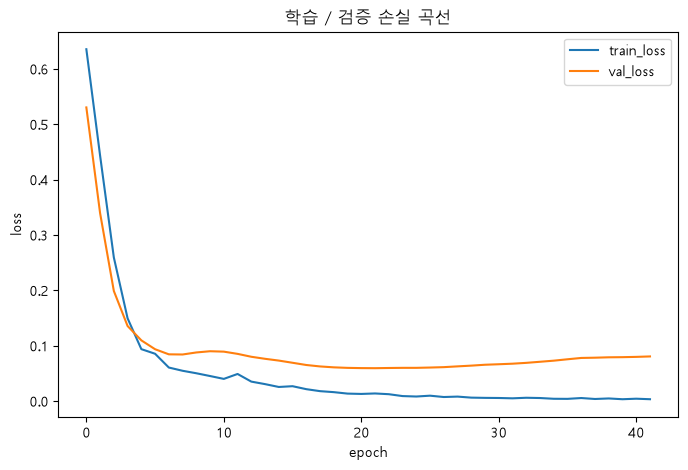

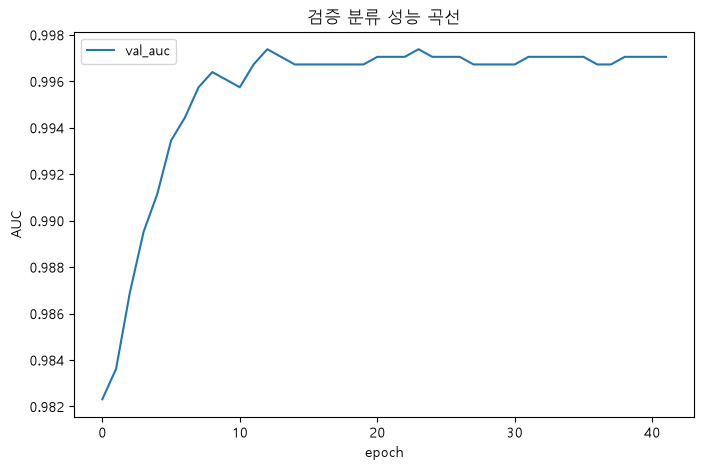

In [293]:
# Train / Valid Loss 학습 곡선, Val Auc
plt.figure(figsize= (8,5))
plt.plot(history['train_loss'], label = 'train_loss')
plt.plot(history['val_loss'], label = 'val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('학습 / 검증 손실 곡선')
plt.legend()
plt.show()


plt.figure(figsize= (8,5))
plt.plot(history['val_auc'], label = 'val_auc') # 검증 AUC
plt.xlabel('epoch')
plt.ylabel('AUC')
plt.title('검증 분류 성능 곡선')
plt.legend()
plt.show()

손실 곡선 : 학습 손실은 줄어드는데 검증은 줄어들지 않으면 과적합 신호로 본다.  

AUC 곡선 : 모델의 전반적인 분류 능력이 어떻게 변하는지 확인  
AUC가 꾸준히 상승하면 클래스 간 구분 능력이 향상되고 있음.

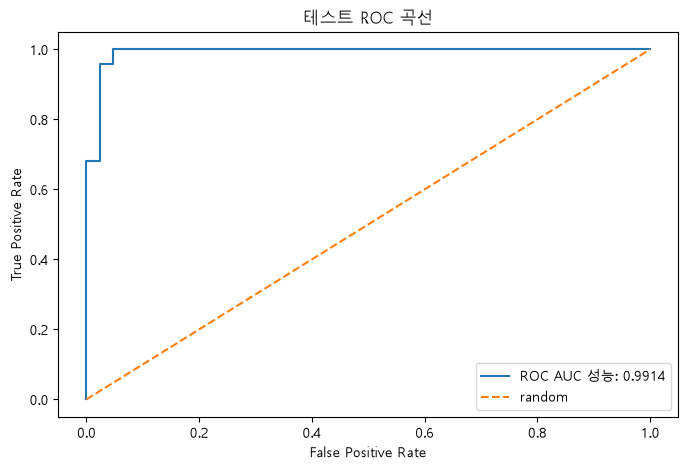

In [294]:
fpr, tpr, thr = roc_curve(y_true, y_prob)   # 실제값과 예측 확률로 ROC 곡선 좌표 계산 (FP 거짓양성, TP 참양성, 임계)

plt.figure(figsize= (8,5))
plt.plot(fpr, tpr, label = f"ROC AUC 성능: {test_auc:.4f}") # 검증 AUC
plt.plot([0,1],[0,1], linestyle ='--', label = 'random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('테스트 ROC 곡선')
plt.legend()
plt.show()

ROC 곡선은 모델이 양성과 음성을 얼마나 잘 구분하는지를 확인할 수 있는 지표이다.  
여기서 AUC는 ROC곡선 아래 면적으로, 무작위로 하나의 양성과 음성을 선택했을 떄 모델이 올바르게 순서를 매길 확률이다.

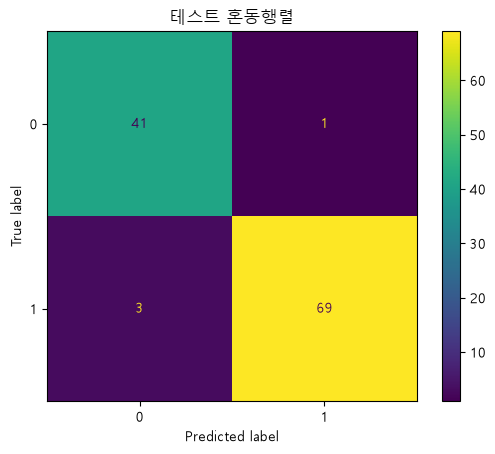

In [295]:
y_pred = (y_prob> 0.5).astype(int)
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix= cm)
disp.plot()
plt.title('테스트 혼동행렬')
plt.show()

혼동행렬은 각 클래스별로 얼마나 맞추고 틀렸는지를 직접적으로 볼 수있다.

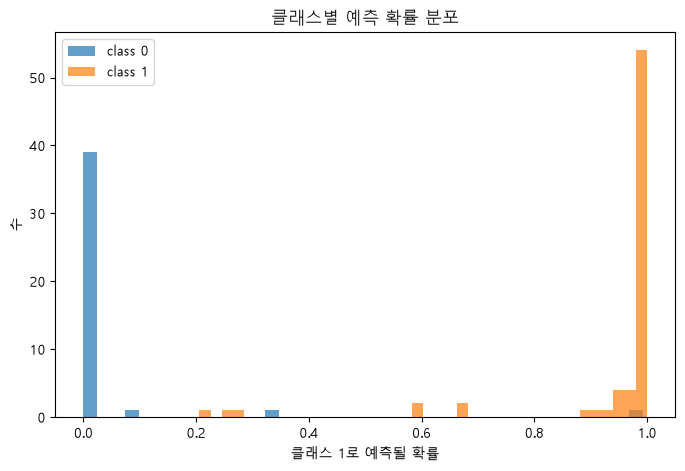

In [296]:
# 클래스별 예측 확률 분포

plt.figure(figsize= (8,5))

plt.hist(
    y_prob[y_true==0],
    bins = 40,
    alpha = 0.7,
    label = 'class 0'
)

plt.hist(
    y_prob[y_true==1],
    bins = 40,
    alpha = 0.7,
    label = 'class 1'
)

plt.xlabel('클래스 1로 예측될 확률')
plt.ylabel('수')
plt.title('클래스별 예측 확률 분포')
plt.legend()
plt.show()

두 클래스가 겹치는 부분은 약간 존재하긴 하지만 그렇게 크지 않음.  
분류 경계가 명확한 편이고, 모델의 확신이 높은편임.

혼자서 공부하면서 적용해볼만 사항  
1. 은닉층 증축 설계 & 하이퍼파라미터 최적화
2. 최적화 함수 변경 (Adam -> AdamW, NAdam, RAdam)
3. 스케일러 변경 (StandardScaler -> MinMaxScaler, RobustScaler)


4. SMOTE (데이터 불균형)
5. 과적합 발생시
    - Dropout / BatchNorm
    - Scheduler : lr를 점진적으로 조절 (ReduceLROnPlateau 등)
    - Early Stopping
    - K-Fold Cross Validation